# Task 3: Gaussian pulse vs DRAG pulse

__实验目标__：对比 Transmon 量子比特在实现 $X$ 门时，高斯脉冲与 DRAG 脉冲的性能差异，重点分析&#x5BF9;__&#x80FD;级泄&#x6F0F;__&#x7684;抑制效果。

__实验内容__：

1. 分别使用高斯脉冲和 DRAG 脉冲实现 $X$ 门，并通过扫描 DRAG 系数 $\beta$ 寻找最优值。
2. 监测能级布居数 $P_0, P_1, P_2$ 的演化。
3. 以 $1 - P_1(\text{final})$ 评估门误差，以 $P_2(\text{final})$ 评估能级泄漏。

__预期结果__：优化后的 DRAG 脉冲能显著降低 $|2\rangle$ 能级的泄漏，提高 $X$ 门的保真度。


In [1]:
from dataclasses import replace
from pathlib import Path

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from musiq.pulse.sequence import PulseCompiler
from musiq.workflow import create_model


MODEL_DIR = Path(".")
FIG_DIR = MODEL_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

## 图 1：Gaussian 和 DRAG 的波形与三能级布居数

本图展示了高斯脉冲与 DRAG 脉冲的时域波形对比及其对应的能级演化。可以看到，DRAG 脉冲通过在正交分量中引入修正项，有效抑制了 $|2\rangle$ 能级的布居数峰值，减少了在 $\pi$ 门操作过程中的相干泄漏。


In [2]:
model = create_model(
    circuits = MODEL_DIR / "circuit.yaml",
    devices = MODEL_DIR / "device.yaml",
    pulses = {
        "gaussian": MODEL_DIR / "pulse_gaussian.yaml",
        "drag": MODEL_DIR / "pulse_drag.yaml"
    },
    solvers = MODEL_DIR / "solver.yaml",
    analysers = MODEL_DIR / "analyser.yaml",
)

model.run_all()

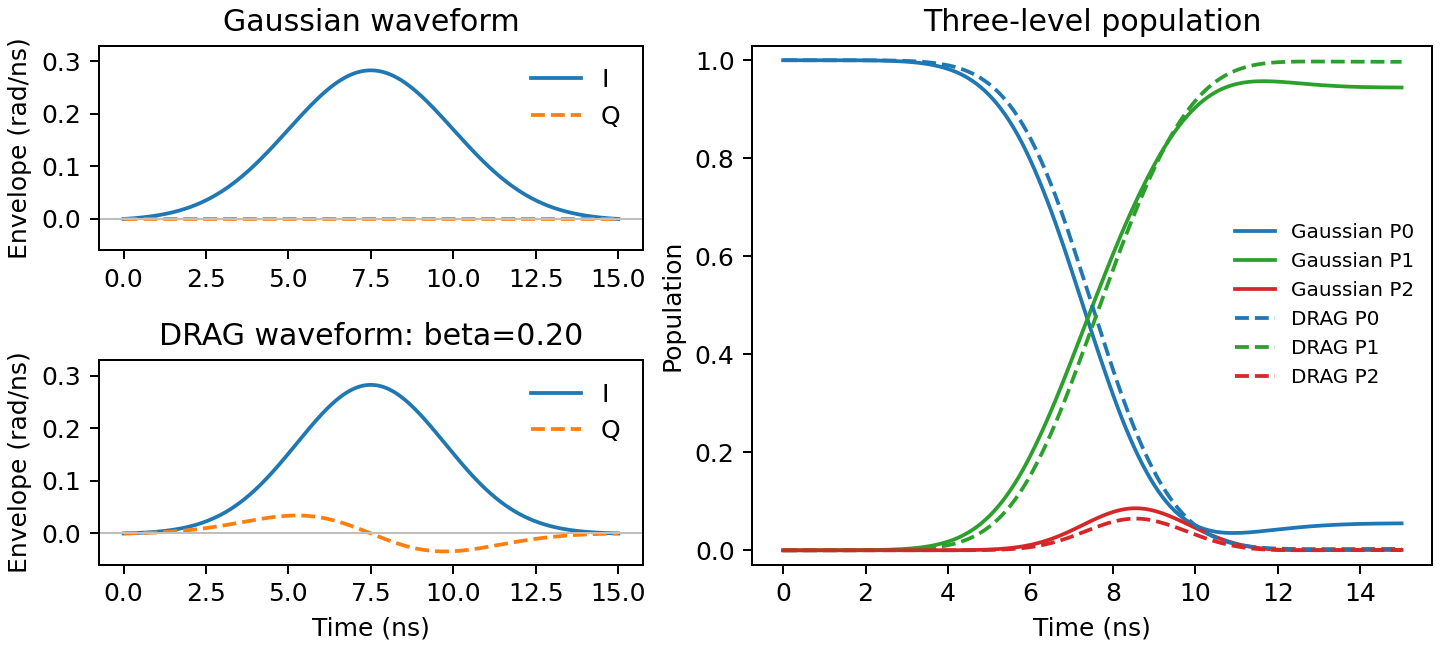

In [3]:
# 1. 定义配置映射，避免重复写两次提取逻辑
cases = {
    "Gaussian": {"run": "pulse_shape_0", "analysis": "case_1", "color": "tab:blue"},
    "DRAG":     {"run": "pulse_shape",   "analysis": "case_0", "color": "tab:orange"}
}

data = {}
for name, cfg in cases.items():
    # 提取并编译波形
    art = model.runs['solver_0'][cfg['run']].artifacts
    ir = replace(art.pulse_ir, t_end_s=art.model_spec.time.t_end_s)
    samples = PulseCompiler.compile(ir, sample_rate_Hz=1e11)
    wf = samples[next(k for k in samples if k.startswith("XY_"))]
    
    # 提取布居数
    pop = model.analyses[cfg['analysis']].metrics['population']
    
    data[name] = {"wf": wf, "pop": pop, "beta": model.config.pulses['drag'].extras['gates']['x']['drag_beta']}

# 2. 绘图
fig = plt.figure(figsize=(8.0, 3.6), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=[1.0, 1.25])
ax_pop = fig.add_subplot(grid[:, 1])
axes_wf = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[1, 0])] # 这里通过 index 对应 Gaussian/DRAG

for i, (name, info) in enumerate(cases.items()):
    ax = axes_wf[i]
    d = data[name]
    
    # 绘制波形 (I 和 Q)
    ax.plot(np.asarray(d['wf']['t']) * 1e9, d['wf']['y'] * 1e-9, label="I")
    q_val = d['wf'].get('y_quadrature', 0 * d['wf']['y'])
    ax.plot(np.asarray(d['wf']['t']) * 1e9, q_val * 1e-9, "--", label="Q")
    
    ax.axhline(0.0, color="0.75", linewidth=0.8)
    ax.set_ylim(-0.06, 0.33)
    ax.set_title(f"{name} waveform" + (f": beta={d['beta']:.2f}" if name=="DRAG" else ""))
    ax.set_ylabel("Envelope (rad/ns)")
    ax.legend(frameon=False, loc="upper right")
    if i == 1: ax.set_xlabel("Time (ns)")

    # 绘制布居数
    labels = ["P0", "P1", "P2"]
    colors = ["tab:blue", "tab:green", "tab:red"]
    for j, (label, color) in enumerate(zip(labels, colors)):
        ax_pop.plot(np.asarray(d['pop'].times) * 1e9, d['pop'].values[str(j)], 
                    linestyle="-" if name=="Gaussian" else "--", 
                    color=color, label=f"{name} {label}")

ax_pop.set_title("Three-level population")
ax_pop.set_xlabel("Time (ns)")
ax_pop.set_ylabel("Population")
ax_pop.set_ylim(-0.03, 1.03)
ax_pop.legend(frameon=False, ncol=1, fontsize=8)

fig1_path = FIG_DIR / "waveform_population.png"
fig.savefig(fig1_path, dpi=180)
plt.close(fig)
display(Image(filename=str(fig1_path)))

## 图 2：扫描 beta 和门时间

本图展示了门保真度（$1 - P_1$）与泄漏率（$P_2$）随 DRAG 系数 $\beta$ 及脉冲时长（Gate Time）的变化情况。结果表明，存在最优的 $\beta$ 值可使泄漏率降至最低，且随着门时间缩短，DRAG 脉冲对泄漏的抑制作用比纯高斯脉冲更为显著。


In [4]:
gate_time_ns = 15.0

model_gaussian = create_model(
    circuits = MODEL_DIR / "circuit.yaml",
    devices = MODEL_DIR / "device.yaml",
    pulses = MODEL_DIR / "pulse_gaussian.yaml",
    solvers = MODEL_DIR / "solver.yaml",
    analysers = MODEL_DIR / "analyser.yaml",
)
model_gaussian.pulse.extras["gate_duration_ns"] = gate_time_ns
model_gaussian.run_all()
gaussian_metrics = model_gaussian.analyses['case_0'].metrics

beta_list = np.linspace(-0.3, 1.3, 41).tolist()
model_drag_beta = create_model(
    circuits = MODEL_DIR / "circuit.yaml",
    devices = MODEL_DIR / "device.yaml",
    pulses = MODEL_DIR / "pulse_drag.yaml",
    solvers = MODEL_DIR / "solver.yaml",
    analysers = MODEL_DIR / "analyser_sweep.yaml",
    parameter_sweep={"pulse:gates.x.drag_beta": beta_list}
)
model_drag_beta.pulse.extras["gates"]['x']['duration_ns'] = gate_time_ns
model_drag_beta.run_all()
drag_beta_metrics = model_drag_beta.analyses['sweep_0'].metrics

min_idx = np.argmin(drag_beta_metrics['final_leakage'].values)
best_beta = beta_list[min_idx]

gatetime_list = np.linspace(5.0, 45.0, 41).tolist()
model_gatetime = create_model(
    circuits = MODEL_DIR / "circuit.yaml",
    devices = MODEL_DIR / "device.yaml",
    pulses = {
        "gaussian": MODEL_DIR / "pulse_gaussian.yaml",
        "drag": MODEL_DIR / "pulse_drag.yaml",
    },
    solvers = MODEL_DIR / "solver.yaml",
    analysers = MODEL_DIR / "analyser_sweep.yaml",
    parameter_sweep={"pulse:gates.x.duration_ns": gatetime_list}
)
model_gatetime.pulse.extras["gates"]['x']['drag_beta'] = best_beta
model_gatetime.run_all()
gatetime_gaussian_metrics = model_gatetime.analyses['sweep_1'].metrics
gatetime_drag_metrics = model_gatetime.analyses['sweep_0'].metrics

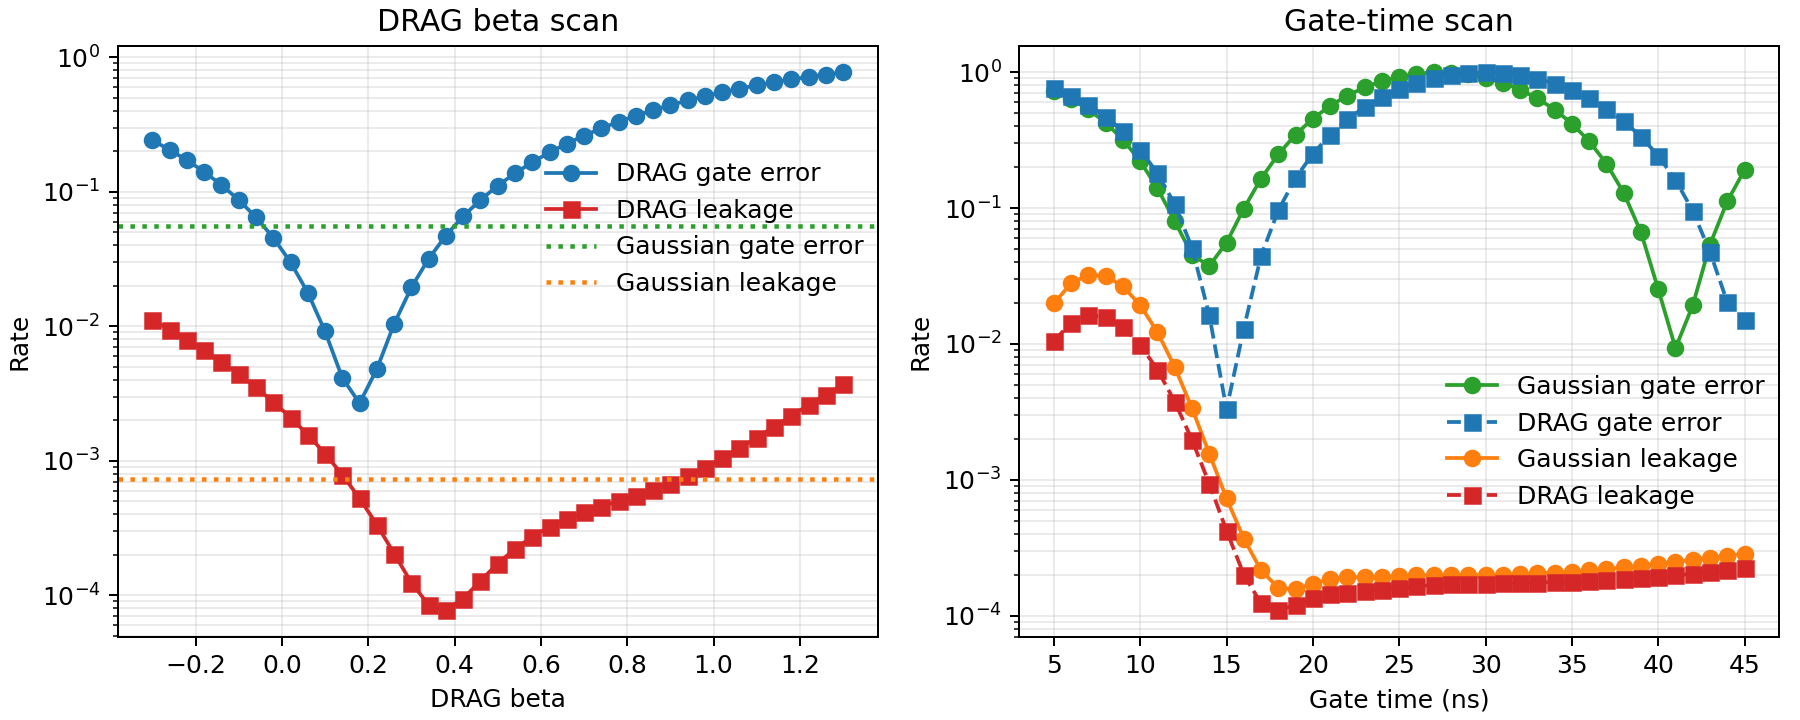

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), constrained_layout=True)

gaussian_metrics = model_gaussian.analyses['case_0'].metrics
drag_beta_metrics = model_drag_beta.analyses['sweep_0'].metrics
ax = axes[0]
ax.semilogy(beta_list, 1 - np.asarray(drag_beta_metrics['final_P1'].values), "o-", label="DRAG gate error", color="tab:blue")
ax.semilogy(beta_list, np.asarray(drag_beta_metrics['final_leakage'].values), "s-", label="DRAG leakage", color="tab:red")
ax.axhline(1-gaussian_metrics['population'].values['1'][-1], color="tab:green", linestyle=":", linewidth=1.8, label="Gaussian gate error")
ax.axhline(gaussian_metrics['leakage'].values[-1], color="tab:orange", linestyle=":", linewidth=1.8, label="Gaussian leakage")
ax.set_title("DRAG beta scan")
ax.set_xlabel("DRAG beta")
ax.set_ylabel("Rate")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, loc=(0.55,0.56))

ax = axes[1]
ax.semilogy(gatetime_list, 1 - np.asarray(gatetime_gaussian_metrics['final_P1'].values), "o-", color="tab:green", label="Gaussian gate error")
ax.semilogy(gatetime_list, 1 - np.asarray(gatetime_drag_metrics['final_P1'].values), "s--", color="tab:blue", label="DRAG gate error")
ax.semilogy(gatetime_list, gatetime_gaussian_metrics['final_leakage'].values, "o-", color="tab:orange", label="Gaussian leakage")
ax.semilogy(gatetime_list, gatetime_drag_metrics['final_leakage'].values, "s--", color="tab:red", label="DRAG leakage")
ax.set_title("Gate-time scan")
ax.set_xlabel("Gate time (ns)")
ax.set_ylabel("Rate")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, loc=(0.55,0.2))

fig2_path = FIG_DIR / "beta_gate_time_scan.png"
fig.savefig(fig2_path, dpi=180)
plt.close(fig)
display(Image(filename=str(fig2_path)))